# Tarea Nº 3 — Inteligencia Artificial

**Estudiante:** Maximiliano Solorza  
**Fecha de entrega:** Domingo 28 de Junio de 2026

In [4]:
# === instalacion librerias necesarias === #
#!pip install numpy pandas matplotlib pgmpy ipywidgets seaborn scikit-learn tensorflow imbalanced-learn tf-keras
%pip install numpy pandas matplotlib pgmpy ipywidgets seaborn scikit-learn tensorflow imbalanced-learn tf-keras
# ======================================== #

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 10.1 MB/s  0:00:49m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 16.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tf-keras]1/2 [tf-keras]
Note: you may need to restart the kernel to use updated packages.


In [9]:
# =================== dependencias del proyecto ==================== #
import os

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn as sk
import tf_keras as keras
from tf_keras import layers, regularizers


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             classification_report, confusion_matrix)
# ================================================================== #

In [18]:
# ============ estilo de los graficos ============ #
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
# ================================================ #

In [10]:
# ======= chequeo de versiones ======= #
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("TensorFlow:", tf.__version__)
print("scikit-learn:", sk.__version__)
# ==================================== #

numpy: 2.5.0
pandas: 3.0.4
TensorFlow: 2.21.0
scikit-learn: 1.9.0


In [13]:
# ======================== carga de los dataset ======================== #
base = "datasets/"

dataframes = {
    "Balanceado":    os.path.join(base, "postures_balanced_50000.csv"),
    "Desbalanceado": os.path.join(base, "postures_imbalanced_50000.csv"),
}

raw = {name: pd.read_csv(path) for name, path in dataframes.items()}

for name, df in raw.items():
    print(f"° {name}, shape: {df.shape}")

print("\nPrimeras filas (Balanceado):")
display(raw["Balanceado"].head())

print("\nPrimeras filas (Desbalanceado):")
display(raw["Desbalanceado"].head())
# ====================================================================== #

° Balanceado, shape: (50000, 23)
° Desbalanceado, shape: (50000, 23)

Primeras filas (Balanceado):


,Class,User,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,...,Z3,X4,Y4,Z4,X5,Y5,Z5,X6,Y6,Z6
0,4,12,61.947275,135.407496,-20.554474,38.682137,89.049858,-8.439905,46.700389,150.469101,...,-30.455520,62.332455,81.884850,-19.691140,45.159813,17.067704,-79.308088,NaN,NaN,NaN
1,1,13,62.799492,50.736675,-68.975138,56.338217,77.474460,-64.680418,59.656012,17.462805,...,-45.737813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,31.487777,85.870298,-47.904666,-10.991409,80.020112,-40.783903,12.858542,83.661513,...,-54.680505,61.226931,56.960649,-59.567917,NaN,NaN,NaN,NaN,NaN,NaN
3,2,14,68.744593,139.890999,8.297129,88.666925,75.668980,-42.573109,0.882151,121.883681,...,-6.692044,16.391990,93.505650,16.652949,73.089022,57.978044,-46.237332,21.047267,140.854416,39.985918
4,4,13,43.607745,144.183804,11.788656,61.446513,135.027272,3.987780,82.103598,74.991998,...,3.191450,58.724120,94.983372,-0.770625,65.004897,18.997488,-57.759273,77.840263,49.234491,-57.326648



Primeras filas (Desbalanceado):


,Class,User,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,...,Z3,X4,Y4,Z4,X5,Y5,Z5,X6,Y6,Z6
0,3,8,27.223664,81.749158,-51.329624,105.730511,19.628531,-92.542984,58.585362,137.272136,...,-34.421747,82.600168,14.240770,-90.563749,3.731535,82.396533,-44.331580,60.300927,-6.138673,-78.992701
1,1,13,62.799492,50.736675,-68.975138,56.338217,77.474460,-64.680418,59.656012,17.462805,...,-45.737813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,31.487777,85.870298,-47.904666,-10.991409,80.020112,-40.783903,12.858542,83.661513,...,-54.680505,61.226931,56.960649,-59.567917,NaN,NaN,NaN,NaN,NaN,NaN
3,1,12,69.731431,68.097701,-48.749863,-10.081609,82.377167,-35.627840,46.762607,9.792311,...,-38.051597,43.151214,78.818724,-43.225743,46.142755,49.030409,-95.980369,NaN,NaN,NaN
4,3,11,52.475086,93.050853,7.763829,49.576891,132.613513,17.422233,74.386492,17.077776,...,-50.050866,116.092302,47.785267,-48.935800,11.588880,87.100435,-27.528267,NaN,NaN,NaN


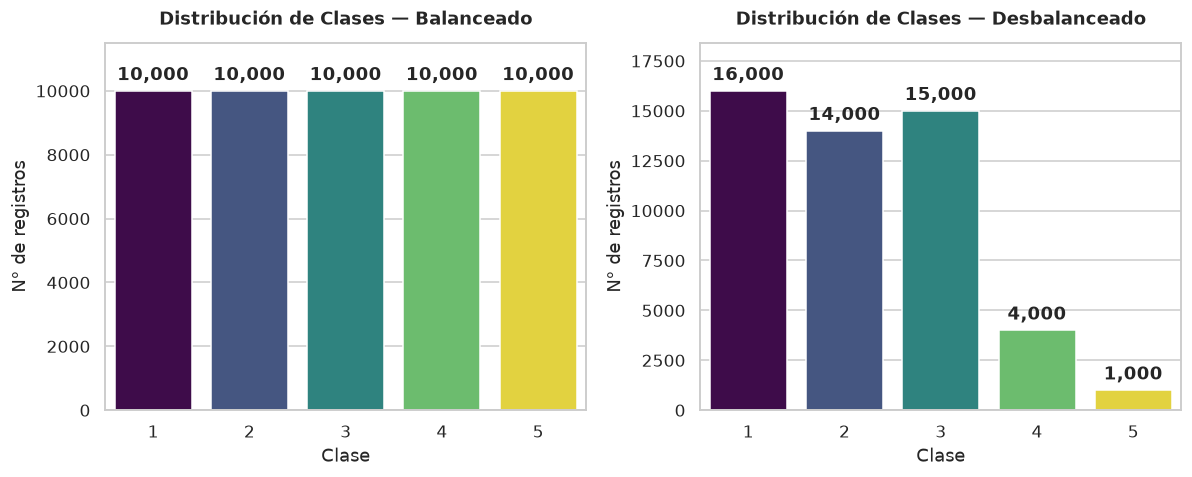

Proporciones por clase:


,Balanceado,Desbalanceado
Clase,,
1,20.00%,32.00%
2,20.00%,28.00%
3,20.00%,30.00%
4,20.00%,8.00%
5,20.00%,2.00%


In [ ]:
# ===================== graficos para revisar la distribución ===================== #
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, df) in zip(axes, raw.items()):
    counts = df["Class"].value_counts().sort_index()
    
    sns.barplot(
        x=counts.index, 
        y=counts.values, 
        ax=ax, 
        hue=counts.index,
        palette="viridis", 
        legend=False
    )
    
    ax.set_title(f"Distribución de Clases — {name}", pad=12, fontweight="bold")
    ax.set_xlabel("Clase")
    ax.set_ylabel("N° de registros")
    ax.set_ylim(0, max(counts.values) * 1.15) 
    
    for i, v in enumerate(counts.values):
        ax.text(
            x=i, 
            y=v + (max(counts.values) * 0.02), 
            s=f"{v:,}", 
            ha="center", 
            va="bottom",
            fontweight="bold"
        )

plt.tight_layout()
plt.show()
# ================================================================================= #

# ============================ proporciones por clase ============================= #
prop = pd.DataFrame({
    name: df["Class"].value_counts(normalize=True).sort_index()
    for name, df in raw.items()
})
prop.index.name = "Clase"

print("Proporciones por clase:")
display(prop.style.format("{:.2%}").background_gradient(cmap="Blues", axis=0))
# ================================================================================= #

Diagnóstico de los Datasets Al analizar la columna objetivo Class en ambos archivos mediante las gráficas y la tabla de proporciones, se identifican dos comportamientos radicalmente opuestos:Dataset Balanceado (postures_balanced_50000.csv): Presenta una distribución uniforme perfecta. Cada una de las 5 clases posee exactamente el $20.00\%$ de los registros (aproximadamente 10,000 muestras por clase).Dataset Desbalanceado (postures_imbalanced_50000.csv): Presenta un desequilibrio severo. Las clases 1, 2 y 3 son mayoritarias, acumulando el $90.00\%$ de todo el dataset ($32\%$, $30\%$ y $28\%$ respectivamente). Por el contrario, las clases 4 ($8\%$) y 5 ($2\%$) son minoritarias, siendo la Clase 5 un caso crítico de "escasez de datos".

Si entrenamos la red neuronal con el dataset desbalanceado sin tomar medidas, el modelo sufrirá del "Sesgo de la Mayoría":La red neuronal optimizará sus funciones de pérdida prediciendo casi siempre las clases 1, 2 y 3, ya que haciendo eso asegura un $90\%$ de precisión (Accuracy) automática, ignorando por completo a la clase 5.El Accuracy se convertirá en una métrica mentirosa. Un modelo con $90\%$ de Accuracy parecerá excelente, pero en la realidad será incapaz de detectar la postura 5 (un fallo catastrófico en un sistema real).

ya que el desbalanceado 3 clases tienen el 90% de las muestras el modelo aunque tenga una precicion alta sera clasificando esos datos bla bla

antes de cualquier cosa, como ya se vio en la celda previa existen varios NaN hay que ver el impacto y normalizar


In [27]:
# ================================ análisis de valores faltantes (NaN) =============================== #
feat_cols = [c for c in raw["Balanceado"].columns if c not in ("Class", "User")]

na_table = pd.DataFrame({
    "Cant_Balanceado": raw["Balanceado"][feat_cols].isna().sum(),
    "Cant_Desbalanceado": raw["Desbalanceado"][feat_cols].isna().sum()
})

na_table["%_Balanceado"] = (
    na_table["Cant_Balanceado"] / len(raw["Balanceado"]) * 100).round(2)

na_table["%_Desbalanceado"] = (
    na_table["Cant_Desbalanceado"] / len(raw["Desbalanceado"]) * 100).round(2)

column_order = ["Cant_Balanceado",
                "%_Balanceado",
                "Cant_Desbalanceado",
                "%_Desbalanceado"]

na_table = na_table[column_order]

variables_con_nan = na_table[(na_table["Cant_Balanceado"] + na_table["Cant_Desbalanceado"]) > 0]

print("Valores faltantes detallados por variable:")

display(
    variables_con_nan.style
    .format({"%_Balanceado": "{:.2f}%",
             "%_Desbalanceado": "{:.2f}%", 
             "Cant_Balanceado": "{:,}",
             "Cant_Desbalanceado": "{:,}"})
    .background_gradient(cmap="Reds", subset=["%_Balanceado", "%_Desbalanceado"])
)

print("Impacto total a nivel de filas (muestras incompletas):")

for name, df in raw.items():
    filas_incompletas = df[feat_cols].isna().any(axis=1).sum()
    porcentaje_total = (filas_incompletas / len(df)) * 100
    
    print(f"  ° {name:<14}: {filas_incompletas:,} filas afectadas ({porcentaje_total:.2f}%)")
# ==================================================================================================== #

Valores faltantes detallados por variable:


,Cant_Balanceado,%_Balanceado,Cant_Desbalanceado,%_Desbalanceado
X3,417,0.83%,670,1.34%
Y3,417,0.83%,670,1.34%
Z3,417,0.83%,670,1.34%
X4,"1,862",3.72%,"2,932",5.86%
Y4,"1,862",3.72%,"2,932",5.86%
Z4,"1,862",3.72%,"2,932",5.86%
X5,"7,926",15.85%,"12,219",24.44%
Y5,"7,926",15.85%,"12,219",24.44%
Z5,"7,926",15.85%,"12,219",24.44%
X6,"15,869",31.74%,"23,171",46.34%


Impacto total a nivel de filas (muestras incompletas):
  ° Balanceado    : 15,869 filas afectadas (31.74%)
  ° Desbalanceado : 23,171 filas afectadas (46.34%)


en la tabla anterior se pueded apreciar en la tabla ambos dataset tieenen algenas features vacias, ambos tienen la misma distribucion, es decir los sensores 0 al 2 funcionan perfecto ya que no aparecen en la tabla, por otro lado las features(sessores del 3 al 4) tienen menor porcentaje de perdida incremental hasta los sensores 6, con mayor perdida 30-40 % aprox

Este diagnóstico demuestra que eliminar las filas con NaN (usando comandos como dropna()) sería un error metodológico devastador, ya que destruiría el $31.74\%$ del dataset balanceado y casi la mitad ($46.34\%$) del desbalanceado. Peor aún, en el entorno desbalanceado, borrar filas al azar podría extinguir por completo los pocos registros existentes de la Clase 5 ($2\%$).

Imputación Robusta (SimpleImputer): Se preservarán todas las filas rellenando los NaN mediante la mediana de cada columna, una métrica central que, a diferencia de la media, no se ve afectada por valores atípicos (outliers) causados por fallas en las coordenadas de los sensores.



---
### Declaración de uso de herramientas generativas

Se utilizó asistencia de IA (Claude, Anthropic) con los siguientes propósitos:

- **Visualización de DataFrames:** al llamar `.head()` dos veces en la misma 
  celda, Jupyter solo renderizaba la última tabla.

  prompt: estoy printeando 2 dataset con .head() pero solo se ve el ultimo dataset pero los 2 print muestran los titulos

  solucion: display

---